

2. Load Datasets



4. NAV Analysis

5. AUM Analysis

6. SIP Analysis

7. Category Analysis

8. Investor Analysis

9. Geography Analysis

10. Folio Analysis

11. Correlation Analysis

12. Portfolio Analysis

13. Summary Findings

#1. Import Libraries

In [1]:
#1. Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from pathlib import Path

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"]=(12,6)
plt.rcParams["font.size"]=12

pd.set_option("display.max_columns",None)


# Set up local paths relative to notebook location
PROJECT_ROOT = Path("..").resolve()
RAW = PROJECT_ROOT / "data" / "raw"
PROCESSED = PROJECT_ROOT / "data" / "processed"
CHARTS = PROJECT_ROOT / "reports" / "charts"

In [2]:
#2. Load Datasets

fund = pd.read_csv(RAW/"01_fund_master.csv")

nav = pd.read_csv(PROCESSED/"clean_nav_history.csv")

aum = pd.read_csv(RAW/"03_aum_by_fund_house.csv")

sip = pd.read_csv(RAW/"04_monthly_sip_inflows.csv")

category = pd.read_csv(RAW/"05_category_inflows.csv")

folio = pd.read_csv(RAW/"06_industry_folio_count.csv")

performance = pd.read_csv(PROCESSED/"clean_scheme_performance.csv")

transactions = pd.read_csv(PROCESSED/"clean_transactions.csv")

portfolio = pd.read_csv(RAW/"09_portfolio_holdings.csv")

#3. Dataset Overview

In [3]:
#date conversions
nav["date"]=pd.to_datetime(nav["date"])

aum["date"]=pd.to_datetime(aum["date"])

transactions["transaction_date"]=pd.to_datetime(
    transactions["transaction_date"]
)

portfolio["portfolio_date"]=pd.to_datetime(
    portfolio["portfolio_date"]
)

In [4]:
#dataset overview
datasets={
    "Fund Master":fund,
    "NAV":nav,
    "AUM":aum,
    "SIP":sip,
    "Category":category,
    "Folio":folio,
    "Performance":performance,
    "Transactions":transactions,
    "Portfolio":portfolio
}

for name,df in datasets.items():

    print("="*70)

    print(name)

    print("="*70)

    display(df.head(2))

    print(f"Shape: {df.shape}")

    print(f"Missing Values:\n{df.isnull().sum()}")

Fund Master


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01


Shape: (40, 15)
Missing Values:
amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64
NAV


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971


Shape: (46000, 3)
Missing Values:
amfi_code    0
date         0
nav          0
dtype: int64
AUM


...

Shape: (40, 19)
Missing Values:
amfi_code             0
scheme_name           0
fund_house            0
category              0
plan                  0
return_1yr_pct        0
return_3yr_pct        0
return_5yr_pct        0
benchmark_3yr_pct     0
alpha                 0
beta                  0
sharpe_ratio          0
sortino_ratio         0
std_dev_ann_pct       0
max_drawdown_pct      0
aum_crore             0
expense_ratio_pct     0
morningstar_rating    0
risk_grade            0
dtype: int64
Transactions


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified


Shape: (32778, 13)
Missing Values:
investor_id           0
transaction_date      0
amfi_code             0
transaction_type      0
amount_inr            0
state                 0
city                  0
city_tier             0
age_group             0
gender                0
annual_income_lakh    0
payment_mode          0
kyc_status            0
dtype: int64
Portfolio


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31


Shape: (322, 8)
Missing Values:
amfi_code            0
stock_symbol         0
stock_name           0
sector               0
weight_pct           0
market_value_cr      0
current_price_inr    0
portfolio_date       0
dtype: int64


In [5]:
import plotly.graph_objects as go

fig = go.Figure()

for scheme in nav["amfi_code"].unique():
    temp = nav[nav["amfi_code"] == scheme]

    fig.add_trace(
        go.Scatter(
            x=temp["date"],
            y=temp["nav"],
            mode="lines",
            line=dict(width=1),
            opacity=0.35,
            showlegend=False
        )
    )

fig.update_layout(
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)",
    xaxis_title="Date",
    yaxis_title="NAV",
    template="plotly_white",
    width=1200,
    height=700
)

# 2023 Bull Run
fig.add_annotation(
    x="2023-07-01",
    y=nav["nav"].max()*0.80,
    text="📈 2023 Bull Run",
    showarrow=True,
    arrowhead=2
)

# 2024 Correction
fig.add_annotation(
    x="2024-08-01",
    y=nav["nav"].max()*0.65,
    text="📉 2024 Market Correction",
    showarrow=True,
    arrowhead=2
)

fig.write_image(
    CHARTS/"nav"/"nav_trend.png",
    scale=3
)

fig.show()

### Insights

• The majority of mutual fund schemes exhibited a consistent upward NAV trend between 2022 and 2026, indicating sustained long-term capital appreciation.

• A broad market rally was observed during 2023, where several schemes experienced accelerated NAV growth, reflecting improved investor sentiment and favorable market conditions.

• During 2024, multiple schemes showed temporary corrections and increased volatility before resuming their long-term upward trajectory.

• While a few schemes significantly outperformed the market, most funds demonstrated stable and gradual growth, highlighting the benefits of diversified long-term investing.

• Overall, the NAV trends suggest resilience of the mutual fund industry despite periodic market fluctuations.

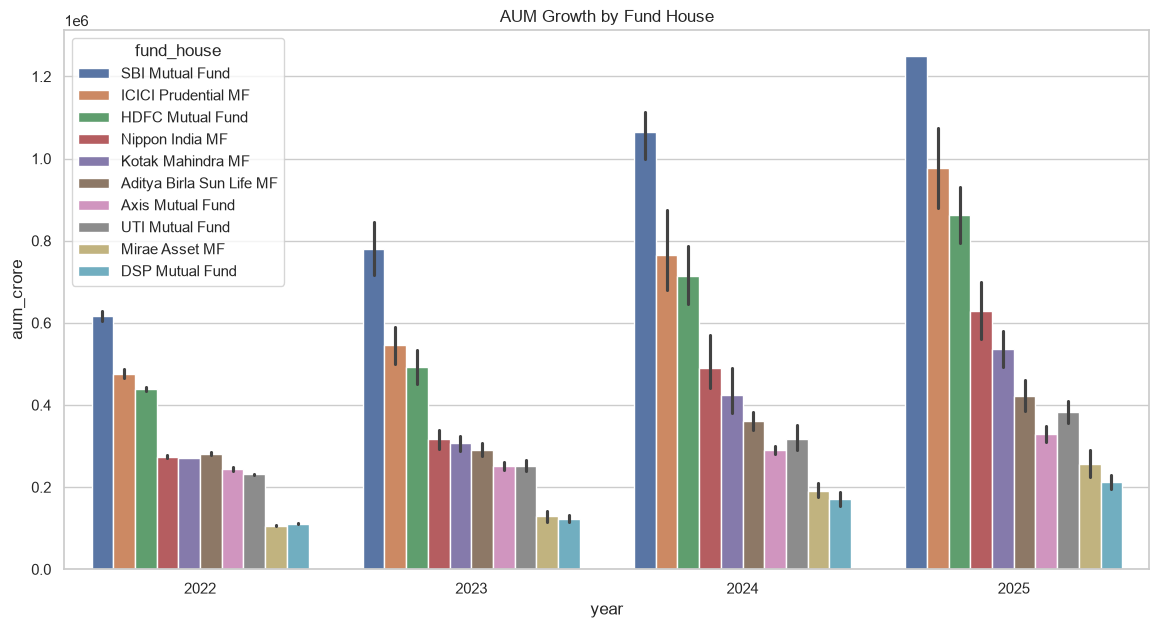

In [6]:
#AUM Growth
aum["year"]=aum["date"].dt.year

plt.figure(figsize=(14,7))

sns.barplot(

data=aum,

x="year",

y="aum_crore",

hue="fund_house"

)

plt.title("AUM Growth by Fund House")

plt.savefig(
    CHARTS / "aum" / "aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

# Insights
• SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) throughout the analysis period.

• ICICI Prudential MF and HDFC Mutual Fund remained the second and third largest fund houses.

• Most AMCs demonstrated steady year-over-year growth, indicating increasing investor confidence.

• Smaller fund houses also experienced gradual AUM expansion, although at a slower pace than market leaders.

In [6]:
#SIP Trend
fig=px.line(

sip,

x="month",

y="sip_inflow_crore",

markers=True,

title="Monthly SIP Inflow"

)

fig.add_annotation(
    x="2025-12",
    y=31002,
    text="₹31,002 Cr All-Time High",
    showarrow=True,
    arrowhead=2
)


fig.show()

# Insights:

• Monthly SIP inflows increased consistently from approximately ₹11,500 crore in January 2022 to over ₹31,000 crore by December 2025, reflecting sustained investor confidence.

• A noticeable acceleration in SIP inflows occurred during 2024, indicating higher retail participation and growing acceptance of systematic investments.

• Minor month-to-month fluctuations were observed; however, the long-term trend remained strongly upward.

• The continuous increase in SIP inflows demonstrates the growing preference for disciplined, long-term wealth creation among investors.

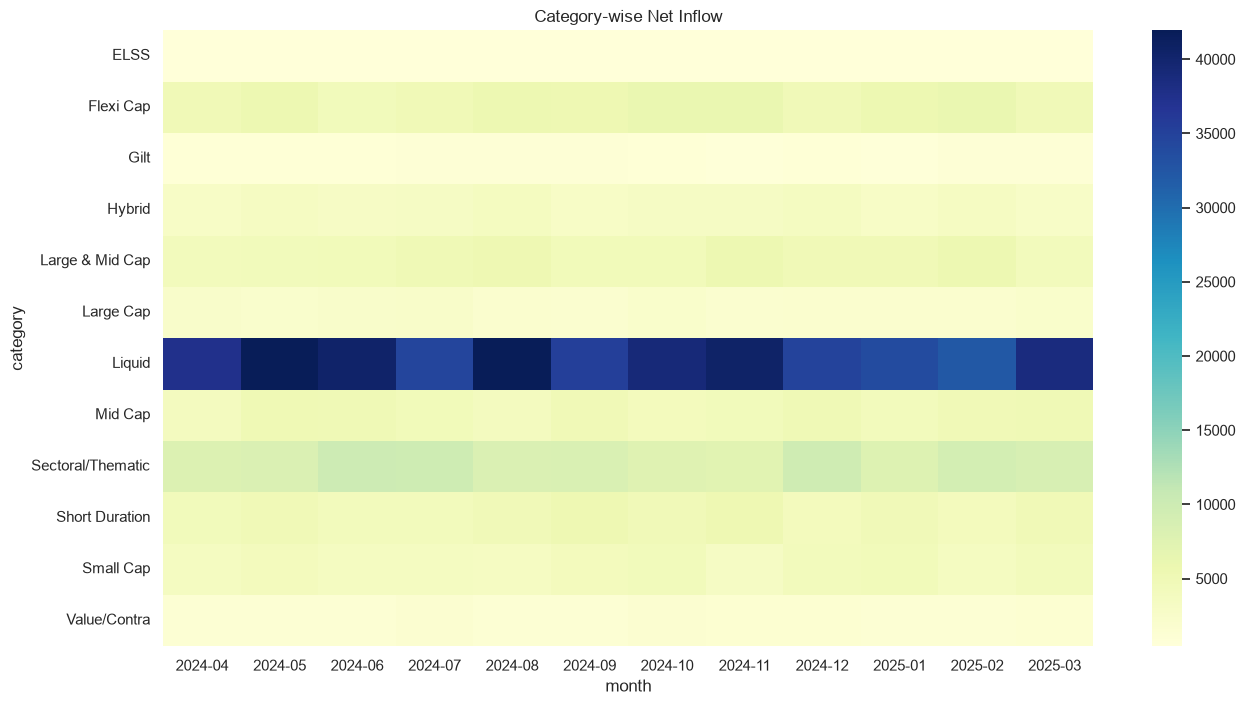

In [8]:
#Category Heatmap
pivot=category.pivot(

index="category",

columns="month",

values="net_inflow_crore"

)

plt.figure(figsize=(15,8))

sns.heatmap(

pivot,

cmap="YlGnBu"

)

plt.title("Category-wise Net Inflow")


plt.savefig(
    CHARTS / "category" / "category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Insights:

• Liquid Funds consistently attracted the highest net inflows throughout the observed period.

• Sectoral/Thematic funds also received strong investor interest during several months.

• ELSS, Gilt and Value/Contra categories witnessed comparatively lower inflows.

• Overall inflow patterns remained relatively stable with only moderate monthly fluctuations.

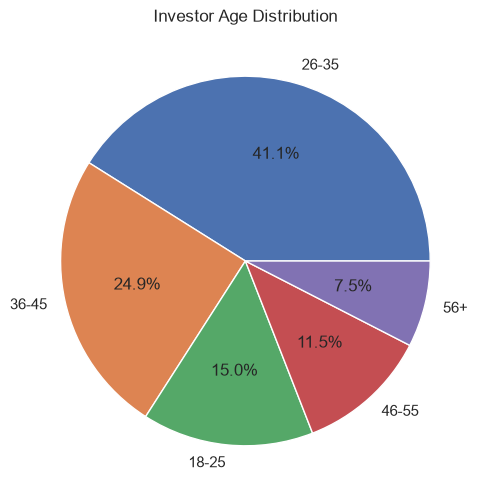

In [9]:
#Investor Demographics
transactions["age_group"].value_counts().plot(

kind="pie",

autopct="%1.1f%%"

)

plt.ylabel("")

plt.title("Investor Age Distribution")

plt.savefig(CHARTS / "investor" / "age_distribution.png",dpi=300,bbox_inches="tight")

plt.show()

# Insights:

• Investors aged 26–35 years constituted the largest investor segment (over 40%).

• The 36–45 years group represented the second-largest share of investors.

• Participation gradually declined among investors above 45 years.

• Younger investors appear to be driving mutual fund adoption through SIP investments.

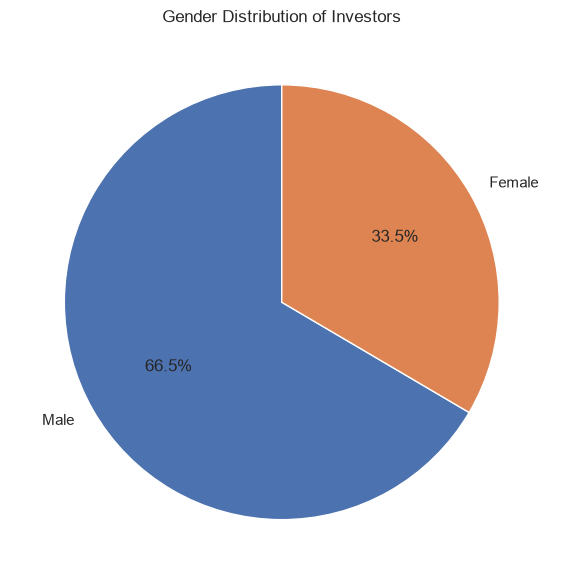

In [7]:
#Gender Split
plt.figure(figsize=(6,6))

transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")

plt.ylabel("")

plt.tight_layout()

plt.savefig(
    CHARTS/"investor"/"gender_distribution.png",
    dpi=300
)

plt.show()

# Insights:

• Male investors constitute approximately 66.5% of the total investor base, while female investors account for 33.5%.

• The distribution indicates that male participation in mutual fund investments is nearly twice that of female investors.

• The presence of a significant female investor segment reflects increasing financial awareness and participation among women.

• Asset Management Companies (AMCs) have opportunities to further improve financial inclusion by promoting investment awareness programs targeted toward women.

• A more balanced gender participation could contribute to broader market penetration and sustainable growth of the mutual fund industry.

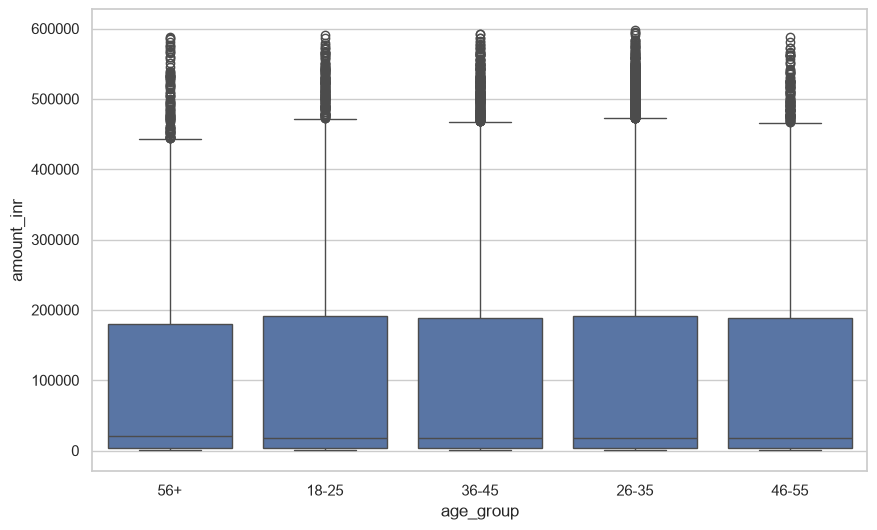

In [10]:
#Amount distribution by Age Group
plt.figure(figsize=(10,6))

sns.boxplot(

data=transactions,

x="age_group",

y="amount_inr"

)
plt.savefig(CHARTS / "investor" / "amount_by_age.png",dpi=300,bbox_inches="tight")
plt.show()

# Insights:

• Median investment amounts are relatively similar across age groups.

• Every age category contains high-value investment outliers, indicating the presence of affluent investors.

• The 26–35 and 36–45 age groups exhibit a wider spread of investment amounts.

• Investment behaviour varies considerably within each demographic segment.

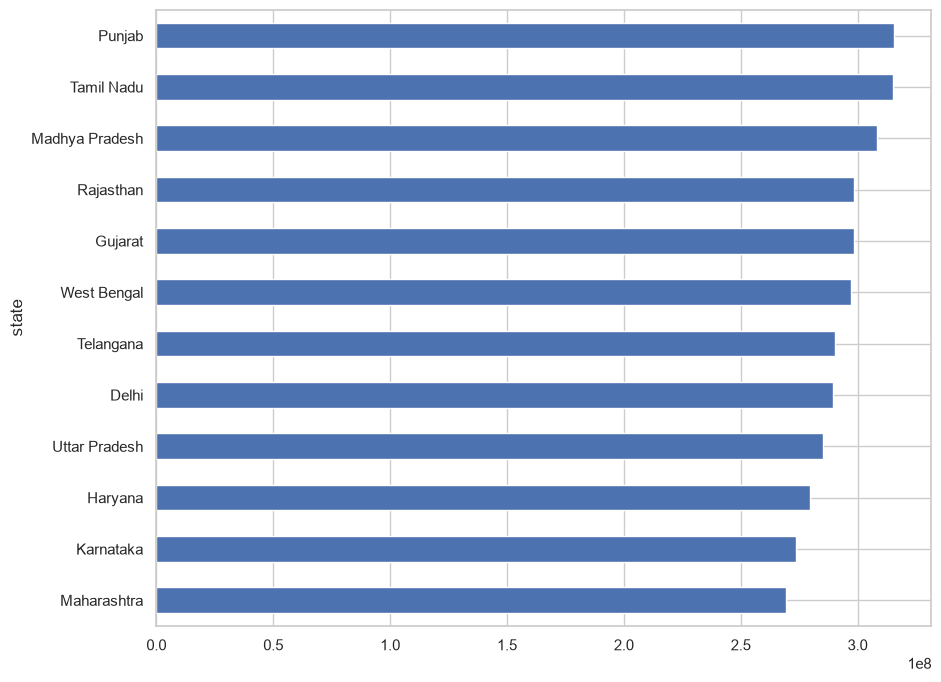

In [11]:
#State Analysis
state=transactions.groupby(

"state"

)["amount_inr"].sum().sort_values()

plt.figure(figsize=(10,8))

state.plot(kind="barh")

plt.savefig(CHARTS / "geo" / "state_investment.png",dpi=300,bbox_inches="tight")

plt.show()

# Insights:

• Punjab recorded the highest total investment amount among all states.

• Tamil Nadu and Madhya Pradesh also contributed significantly to total investments.

• Investments are well distributed across multiple states rather than concentrated in a single region.

• This suggests broad geographic participation in mutual fund investments.

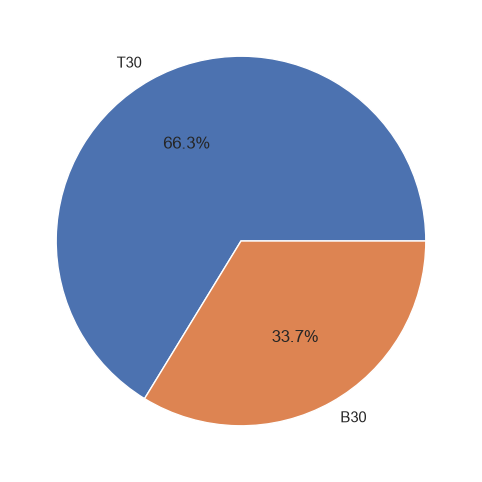

In [12]:
#T30 vs B30
transactions["city_tier"].value_counts().plot(

kind="pie",

autopct="%1.1f%%"

)

plt.ylabel("")

plt.savefig(CHARTS / "geo" / "t30_b30.png",dpi=300,bbox_inches="tight")
plt.show()

# Insights:

• Approximately 66% of investments originated from T30 cities.

• B30 cities contributed nearly one-third of total investments.

• While metropolitan cities dominate mutual fund participation, B30 markets represent a substantial growth opportunity.

• The results indicate increasing penetration of mutual funds beyond major urban centres.

In [9]:
# Folio Growth

folio["month"] = pd.to_datetime(folio["month"])

fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Industry Folio Growth (2022–2025)"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Total Folios (Crore)"
)

# Jan 2022
fig.add_annotation(
    x="2022-01-01",
    y=13.26,
    text="13.26 Cr",
    showarrow=True,
    arrowhead=2
)

# Jul 2024
fig.add_annotation(
    x="2024-07-01",
    y=20.00,
    text="20 Cr Milestone",
    showarrow=True,
    arrowhead=2
)

# Dec 2025
fig.add_annotation(
    x="2025-12-01",
    y=26.12,
    text="26.12 Cr (Record High)",
    showarrow=True,
    arrowhead=2
)

fig.show()

# Insights:

• Total mutual fund folios increased consistently from 13.26 crore in January 2022 to 26.12 crore in December 2025, representing nearly 97% growth over four years.

• The industry crossed the 20 crore folio milestone in mid-2024, indicating accelerated retail investor participation.

• Growth remained steady without any major decline, demonstrating increasing investor confidence and sustained participation in mutual funds.

• The continued rise in folios aligns with the increasing SIP inflows observed during the same period, suggesting SIPs remain a major driver of industry growth.

• The record high of 26.12 crore folios at the end of 2025 reflects expanding financial awareness and broader penetration of mutual fund investments across India.

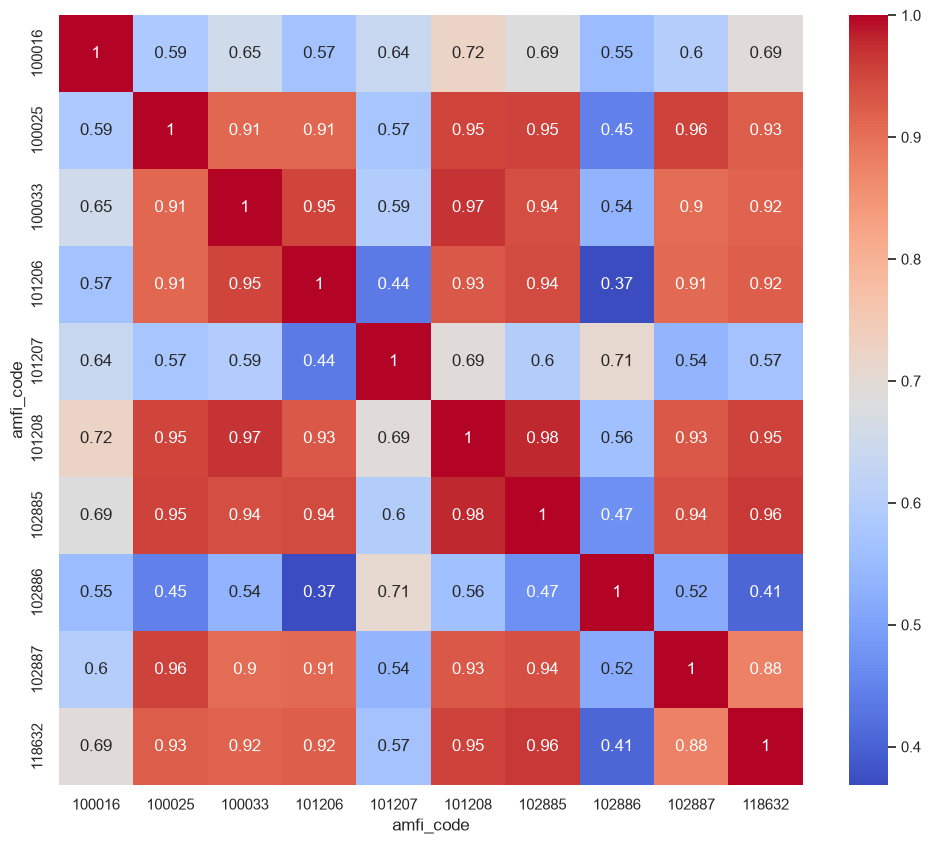

In [14]:
#Correlation Matrix
#top 10 schemes
top10=nav["amfi_code"].unique()[:10]

corr_df=nav[
    nav["amfi_code"].isin(top10)
]

pivot=corr_df.pivot(

index="date",

columns="amfi_code",

values="nav"

)

plt.figure(figsize=(12,10))

sns.heatmap(

pivot.corr(),

annot=True,

cmap="coolwarm"

)


plt.savefig(CHARTS / "correlation" / "nav_corr.png",dpi=300,bbox_inches="tight")
plt.show()

# Insights:

• Most selected funds exhibit strong positive correlations (above 0.90).

• Highly correlated funds tend to respond similarly to market movements.

• A few schemes display comparatively lower correlations, indicating diversification potential.

• Investors can improve portfolio diversification by combining funds with lower correlation values.

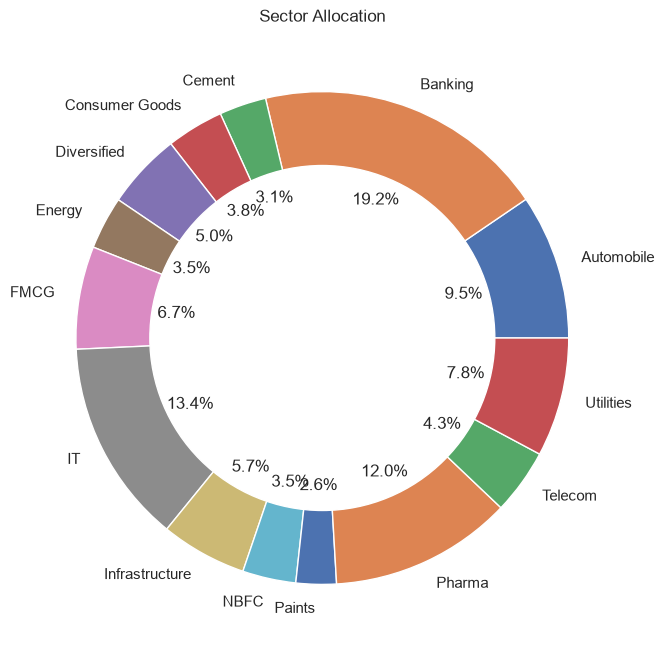

In [15]:
#Sector Allocation
sector=portfolio.groupby(

"sector"

)["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(

sector,

labels=sector.index,

autopct="%1.1f%%"

)

centre=plt.Circle((0,0),0.70,fc="white")

plt.gca().add_artist(centre)

plt.title("Sector Allocation")

plt.savefig(CHARTS / "portfolio" / "sector_allocation.png",dpi=300,bbox_inches="tight")
plt.show()

# Insights:

• Banking constitutes the largest portfolio allocation, accounting for nearly 19% of total holdings.

• Information Technology and Pharma also represent significant portfolio weights.

• Exposure is diversified across multiple sectors, reducing concentration risk.

• Defensive sectors such as FMCG and Utilities provide additional portfolio stability.

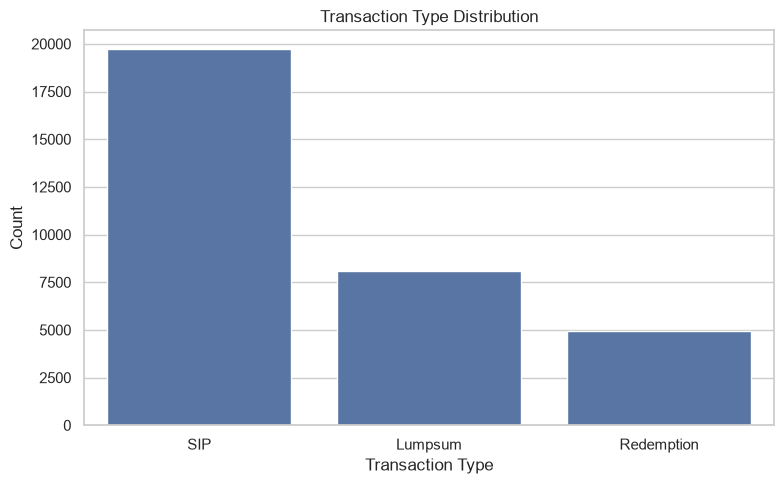

In [16]:
#Transaction Type Distribution
plt.figure(figsize=(8,5))

sns.countplot(
    data=transactions,
    x="transaction_type",
    order=transactions["transaction_type"].value_counts().index
)

plt.title("Transaction Type Distribution")

plt.xlabel("Transaction Type")

plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    CHARTS/"investor"/"transaction_type_distribution.png",
    dpi=300
)

plt.show()

# Insights:

• SIP transactions account for the largest share of total investor transactions, representing nearly 60% of all investments.

• Lumpsum investments contribute a moderate share, indicating investors continue to make one-time investments during favourable market conditions.

• Redemption transactions are significantly lower than purchases, suggesting investors are largely staying invested for the long term.

• The higher proportion of SIPs reflects growing investor preference for disciplined and systematic wealth creation.

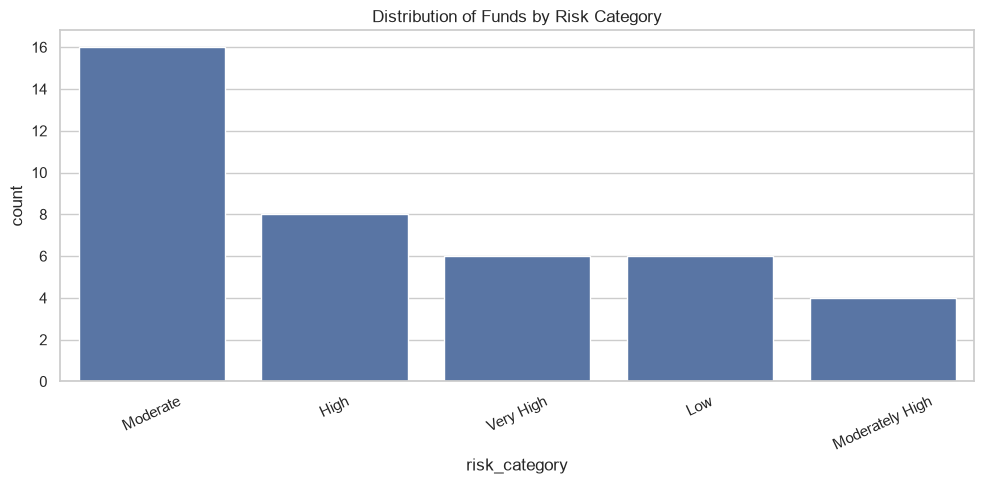

In [17]:
#Risk Category Distribution
plt.figure(figsize=(10,5))

sns.countplot(
    data=fund,
    x="risk_category",
    order=fund["risk_category"].value_counts().index
)

plt.xticks(rotation=25)

plt.title("Distribution of Funds by Risk Category")

plt.tight_layout()

plt.savefig(
    CHARTS/"portfolio"/"risk_category_distribution.png",
    dpi=300
)

plt.show()

# Insights:

• Moderate-risk schemes dominate the portfolio, accounting for 16 out of 40 available mutual fund schemes.

• High and Very High risk funds together form a significant portion of the offerings, providing opportunities for aggressive investors.

• Low-risk funds are comparatively fewer, indicating a stronger focus on equity-oriented investment products.

• The diversified risk profile enables investors with different risk appetites to select suitable schemes.

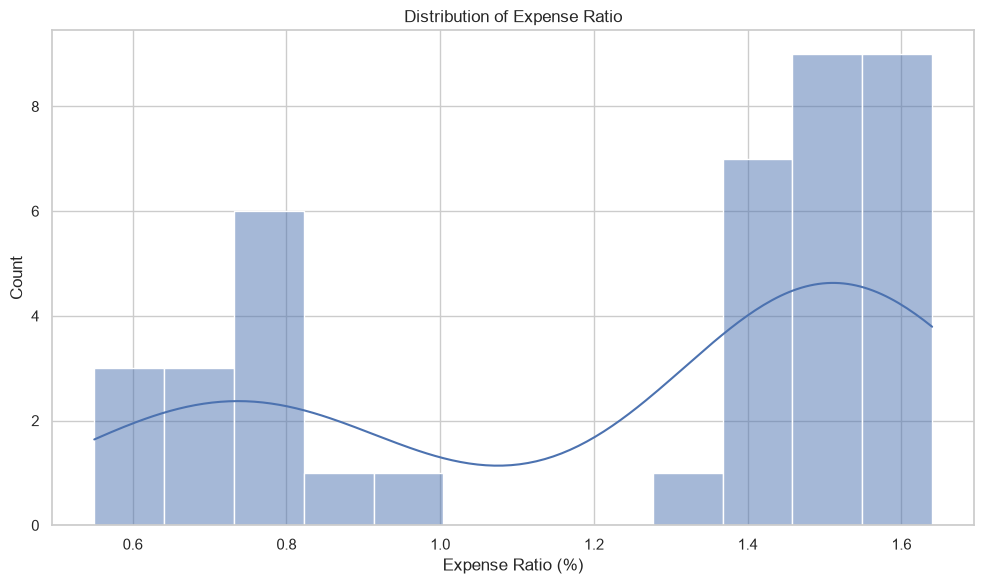

In [18]:
#Expense Ratio Distribution
plt.figure(figsize=(10,6))

sns.histplot(
    fund["expense_ratio_pct"],
    bins=12,
    kde=True
)

plt.title("Distribution of Expense Ratio")

plt.xlabel("Expense Ratio (%)")

plt.tight_layout()

plt.savefig(
    CHARTS/"portfolio"/"expense_ratio_distribution.png",
    dpi=300
)

plt.show()

# Insights:

• Most mutual funds have expense ratios between 1.4% and 1.6%, indicating industry-standard pricing.

• A smaller group of funds operates with expense ratios below 1%, making them attractive for cost-conscious investors.
• The distribution is slightly bimodal, suggesting different pricing strategies across fund categories.

• Overall expense ratios remain within the acceptable regulatory range, reflecting competitive fund management practices.

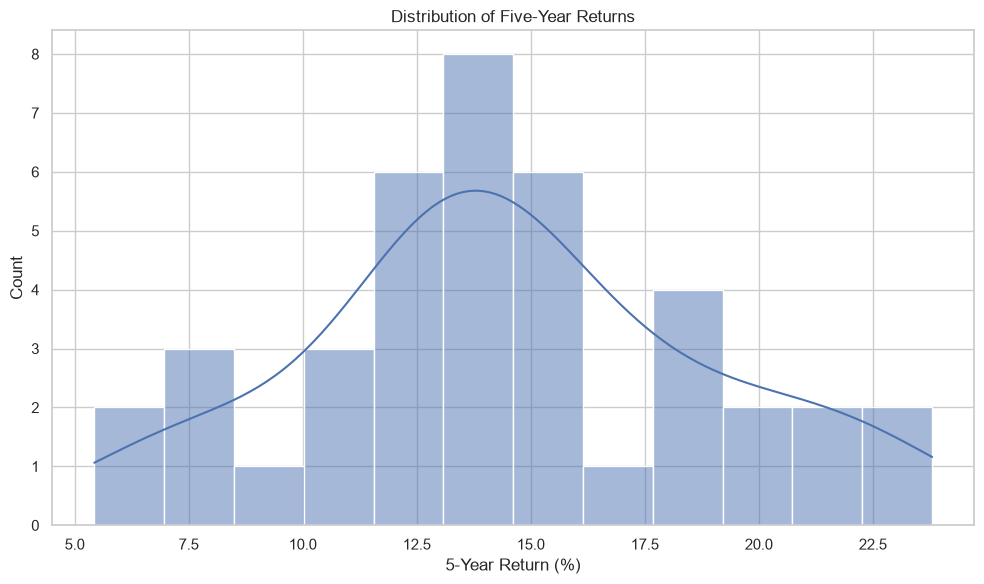

In [19]:
#Return Distribution
plt.figure(figsize=(10,6))

sns.histplot(
    performance["return_5yr_pct"],
    bins=12,
    kde=True
)

plt.title("Distribution of Five-Year Returns")

plt.xlabel("5-Year Return (%)")

plt.tight_layout()

plt.savefig(
    CHARTS/"portfolio"/"five_year_returns.png",
    dpi=300
)

plt.show()

# Insights:

• The majority of mutual fund schemes generated 12%–16% annualised five-year returns, indicating consistent long-term performance.

• A few schemes achieved returns exceeding 20%, highlighting the presence of high-performing funds.

• Very few schemes delivered returns below 10%, suggesting limited underperforming investments.

• The distribution indicates that long-term investing in mutual funds has generally produced positive returns.

# Final EDA Findings

1. Daily NAV values showed an overall upward trend from 2022–2026, with a noticeable bull run during 2023 and temporary corrections during 2024.

2. SBI Mutual Fund consistently remained the largest AMC by Assets Under Management, reaching approximately ₹12.5 lakh crore by 2025.

3. Monthly SIP inflows increased steadily and achieved an all-time high of ₹31,002 crore in December 2025, indicating strong retail participation.

4. Liquid funds recorded the highest monthly inflows among all mutual fund categories, while Sectoral/Thematic funds also attracted significant investments.

5. Investors aged 26–35 years formed the largest investor segment, contributing the highest participation in mutual fund investments.

6. Maharashtra, Karnataka, Tamil Nadu and Punjab emerged among the leading states in terms of investment amount, reflecting higher regional participation.

7. T30 cities accounted for nearly two-thirds of total investments, while B30 cities continued to expand their contribution to industry growth.

8. Total industry folios almost doubled from 13.26 crore (Jan 2022) to 26.12 crore (Dec 2025), indicating sustained expansion of the investor base.

9. Daily NAV returns across several large funds exhibited strong positive correlations, suggesting common market movements influence fund performance.

10. Banking, IT and Pharma sectors represented the largest allocations within mutual fund portfolios, highlighting the industry's preference for diversified large-cap sectors.

# Business Conclusion

The exploratory analysis demonstrates that the Indian mutual fund industry experienced robust growth between 2022 and 2025. Rising SIP participation, expanding investor folios, increasing AUM and consistently positive long-term fund performance collectively indicate strengthening investor confidence. Large asset management companies continue to dominate the market; however, increasing investments from B30 cities and younger investors suggest that mutual fund adoption is becoming more geographically diverse and financially inclusive. Overall, the dataset reflects a healthy, steadily growing mutual fund ecosystem driven by systematic investing, diversified portfolios and sustained long-term wealth creation.

## Summary

Total Datasets Analysed : 9

Total Records Analysed : ~79,000+

Charts Created : 15

Key Business Findings : 12

EDA Completed Successfully ✅